In [1]:
123

123

In [2]:
!curl -L -o ratings_train.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt  # 학습용 데이터 파일 다운로드
!curl -L -o ratings_test.txt  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt   # 테스트용 데이터 파일 다운로드

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 13.95M 100 13.95M   0      0  9.30M      0   00:01   00:01              0
100 13.95M 100 13.95M   0      0  9.30M      0   00:01   00:01              0
100 13.95M 100 13.95M   0      0  9.29M      0   00:01   00:01              0
curl: (3) URL rejected: No host part in the URL
curl: (6) Could not resolve host: xn--ru4bi6eisq
curl: (6) Could not resolve host: xn--2n1bp39av7g
curl: (6) Could not resolve host: xn--pu5bl5s
curl: (6) Could not resolve host: xn--2j1bj1b12ewtu
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100  4.66M 100  4.66M   0      0  8.10M      0     

In [3]:
import pandas as pd
ratings_train_df = pd.read_csv('ratings_train.txt', sep= '\t')
ratings_test_df = pd.read_csv('ratings_test.txt', sep= '\t')

ratings_train_df.shape, ratings_test_df.shape

((150000, 3), (50000, 3))

In [5]:
ratings_train_df = ratings_train_df.dropna(how = 'any') # 하나라도 결측치가 있으면 해당 행 삭제(기본값)
ratings_test_df = ratings_test_df.dropna(how = 'any')

print(ratings_train_df.isnull().sum())
print(ratings_test_df.isnull().sum())


id          0
document    0
label       0
dtype: int64
id          0
document    0
label       0
dtype: int64


In [6]:
ratings_train_df = ratings_train_df.sample(n = 50000, random_state= 42)
ratings_test_df = ratings_test_df.sample(n = 5000, random_state= 42)

ratings_train_df.shape, ratings_test_df.shape

((50000, 3), (5000, 3))

In [10]:
# 데이터 전처리 함수 생성
import re 
from konlpy.tag import Okt

# 텍스트파일에서 stopwords 리스트 가져오는 함수
def load_stopwords(filepath):
    with open(filepath, 'r', encoding= 'utf-8') as f:
        stopwords = [line.strip() for line in f]       # 줄바꿈/ 공백제거하여 리스트 생성
    return stopwords

# 전처리 함수
def preprocessing(sentence, okt = Okt()):
    sentence = re.sub(r'\n', ' ', sentence)     # 개행문자(줄바꿈) 제거
    sentence = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣ\s]', '', sentence)    # 한글 외 문자 모두제거
    
    tokens = okt.morphs(sentence, stem= True)   # 형태소 분석(어간추출)

    # 파일 경로 받아 불용어 로드하는 함수
    ko_stopwords = load_stopwords('ko_stopwords.txt')
    
    tokens = [token for token in tokens if token not in ko_stopwords]   # 불용어 제거

    return tokens

In [11]:
sample = """ 
    이런 영화 진짜 fantastic!!
    너무 못만들었다.
    그런데 감동이다!!! 😅😂😂😂😂
"""

preprocessing(sample)

['이렇다', '영화', '진짜', '너무', '못', '만들다', '감동', '이다']

In [12]:
ratings_train_df.head()

,id,document,label
128076,7865795,원본이 최고,1
65517,5417631,스릴감과 훈훈함이 있는 영화.,1
85048,8357466,굉장히 저평가되는 영화중 하나라고 생각함,1
118192,8252946,정말영화같은이야기 영화여서 영화같은이야기가 좋다,1
92368,7800452,계기도없는데 이상하다,0


In [13]:
# 텍스트 전처리하고, 학습/테스트 리스트 생성
from tqdm.auto import tqdm

X_train, y_train, X_test, y_test = [],[],[],[]

for index, row in tqdm(ratings_train_df.iterrows()):    # DF 의 행단위 순회
    doc, label = row['document'], row['label']
    X_train.append(preprocessing(doc))      # X 데이터는 전처리 후 수집
    y_train.append(label)
    
for index, row in tqdm(ratings_test_df.iterrows()):
    doc, label = row['document'], row['label']
    X_test.append(preprocessing(doc))
    y_test.append(label)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [14]:
print(len(X_train),len(y_train),len(X_test),len(y_test))

50000 50000 5000 5000


In [16]:
print(X_train[:3])
print(y_train[:3])

print(X_test[:3])
print(y_test[:3])


[['원본', '최고'], ['스릴', '감', '훈훈하다', '영화'], ['굉장하다', '평가', '되다', '영화', '중', '라고', '생각', '함']]
[1, 1, 1]
[['찌다', '여운', '하다', '인생', '최고', '미드'], ['기대', '이다'], ['신나다', '없다', '애니']]
[1, 1, 0]


In [ ]:
# 토큰화 기반 정수 인코딩 준비 및 시퀀스 변환
from tensorflow.keras.preprocessing.text import Tokenizer       # 텍스트 -> 정수 시퀀스 변환 도구
from tensorflow.keras.preprocessing.sequence import pad_sequences   # 패딩(길이 통일) 도구

vocab_size = 20000      # 단어 사전 크기(빈도 기준 상위 20000개)

tokenizer = Tokenizer(num_words = vocab_size, oov_token = '<OOV>')  # 사전에 없는 단어는 OOV 처리

tokenizer.fit_on_texts(X_train)     # 학습 데이터로 단어사전(word_index) 학습 (생성)
X_train_encoded = tokenizer.texts_to_sequences(X_train) # 학습 텍스트를 정수 시퀀스로 변환
X_test_encoded = tokenizer.texts_to_sequences(X_test)   # 

print(X_train_encoded[:3])
print(X_test_encoded[:3])

[[8735, 28], [471, 295, 794, 2], [648, 409, 16, 2, 55, 126, 32, 209]]
[[1066, 240, 4, 138, 28, 1473], [227, 9], [1540, 8, 262]]


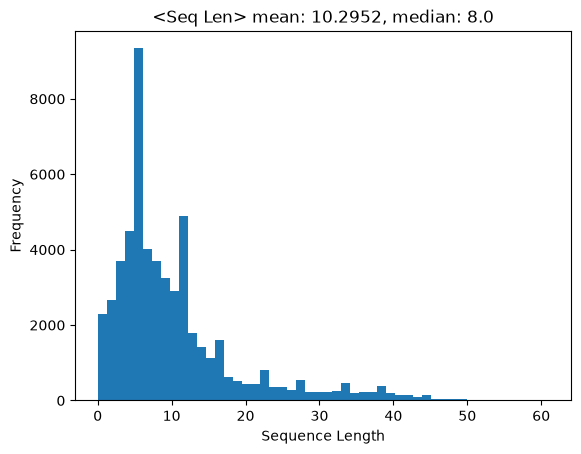

In [21]:
# 패딩 적정 길이 조사
import matplotlib.pyplot as plt
import numpy as np

X_train_len = [len(seq) for seq in X_train_encoded]     # 각 샘플 시퀀스 길이 리스트
X_test_len = [len(seq) for seq in X_test_encoded]     # 각 샘플 시퀀스 길이 리스트


mean = np.mean(X_train_len + X_test_len)        # 전체(학습+테스트) 시퀀스 길이 평균
median = np.median(X_train_len + X_test_len)    # 전체(학습+테스트) 시퀀스 길이 중앙값


# 히스토그램으로 시각화
plt.hist(X_train_len + X_test_len, bins = 50)
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.title(f"<Seq Len> mean: {mean:.4f}, median: {median}")
plt.show()

In [22]:
max_len = 15
 
X_train_padded = pad_sequences(X_train_encoded, maxlen= max_len)    # max_len 기준 패딩/ 자르기
X_test_padded = pad_sequences(X_test_encoded, maxlen= max_len)



In [25]:
# 정수 시퀀스를 단어로 복원해 사람이 읽을 수 있는 형태로 변환
def decode_sentence(encoded_sentence):
    # 정수 시퀀스를 찾아 해당 인덱스의 단어를 반환(없으면 _)
    decoded = [tokenizer.index_word.get(n, '_') for n in encoded_sentence]  
    return ' '.join(decoded)

print(X_train_padded[0])    # 패딩처리 완료된 정수 시퀀스
print(decode_sentence(X_train_padded[0]))   # 원래의 단어 형태로 복원

print('---')
print(ratings_test_df.iloc[0, 1])   # test 데이터 0번째 리뷰(document) 원문
print(X_test_padded[0])
print(decode_sentence(X_test_padded[0]))

[   0    0    0    0    0    0    0    0    0    0    0    0    0 8735
   28]
_ _ _ _ _ _ _ _ _ _ _ _ _ 원본 최고
---
찐한 여운과 함께...내 인생 최고의 미드
[   0    0    0    0    0    0    0    0    0 1066  240    4  138   28
 1473]
_ _ _ _ _ _ _ _ _ 찌다 여운 하다 인생 최고 미드


In [28]:
import torch
import torch.nn as nn
# 양방향 LSTM 분류모델 : 임베딩 -> 양방향 LSTM -> FC 로 감성(이진) 분석 logit을 출력하는 모델
class BiLSTMSentimentNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()          # nn.Modele 초기화
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx= 0)    # 임베딩 (0은 학습영향 최소화)
        # LSTM 입력 : 임베딩 -> 출력: 은닉상태 / 양방향 LSTM 사용
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first= True, bidirectional= True)     
        self.fc = nn.Linear(hidden_dim * 2, 1)      # 정/역방향 마지막 은닉상태 결합(2H) -> 이진 로짓 1개
        
    # 마지막 은닉상태 (정/역)을 결합해 문장 표현을 만들고 logit 계산    
    def forward(self, x):
        x = self.embedding(x)           # (B, T) -> (B, T, E)
        _, (hidden, _ ) = self.lstm(x)    # output : (B, T, H), hidden : (L *2, B, H)
        
        # 양방향 은닉상태 처리
        forward_pass = hidden[-2]   # 정방향 마지막 레이어 은닉상태 (B, H)
        backward_pass = hidden[-1]  # 역방향 마지막 레이어 은닉상태 (B, H)
        hidden_merged = torch.cat((forward_pass, backward_pass), dim= 1)    # (B, H) + (B, H) -> (B, 2H)

        output = self.fc(hidden_merged)    # 입력 : 마지막 레이어의 마지막 은닉상태 (B, 2H) -> 출력 : (B, 1)
        return output   # sigmoid 적용 전 원시 logit
    

model = BiLSTMSentimentNet(vocab_size, embedding_dim= 100, hidden_dim= 128)
model
        

BiLSTMSentimentNet(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

In [29]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
BiLSTMSentimentNet                       --
├─Embedding: 1-1                         2,000,000
├─LSTM: 1-2                              235,520
├─Linear: 1-3                            257
Total params: 2,235,777
Trainable params: 2,235,777
Non-trainable params: 0

# 모델학습


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Pytorch Tensor 형태로 변환(X 데이터는 LongTensor , y 데이터는 FloatTensor)
X_train_padded = torch.tensor(X_train_padded, dtype= torch.long)
X_test_padded = torch.tensor(X_test_padded, dtype= torch.long)

y_train = torch.tensor(y_train, dtype=torch.float).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float).unsqueeze(1)



In [32]:
print(X_train_padded.shape, X_test_padded.shape)
print(y_train.shape, y_test.shape)

torch.Size([50000, 15]) torch.Size([5000, 15])
torch.Size([50000, 1]) torch.Size([5000, 1])


In [33]:
# DataLoader 구성
from torch.utils.data import random_split, DataLoader, TensorDataset

batch_size = 64
train_size = int(len(X_train_padded)*0.8)       # 80% 학습데이터
val_size = len(X_train_padded) - train_size     # 나머지 20% 검증데이터

# 학습/ 검증 데이터셋 분리(X, y데이터 묶은 후에 랜덤분리) / 테스트 데이터셋 생성
train_dataset, val_dataset = random_split(
    TensorDataset(X_train_padded, y_train), [train_size, val_size]
)

test_dataset = TensorDataset(X_test_padded, y_test)

# 학습용 : 섞어서 배치 생성/ 검증용 : 순서유지 / 테스트용 : 순서유지
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle= True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle= False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle= False)

print(len(train_dataset),len(val_dataset), len(test_dataset))
print(len(train_dataloader), len(val_dataloader), len(test_dataloader))

40000 10000 5000
625 157 79


In [34]:
# 학습준비 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device : {device}")

torch.cuda.empty_cache()

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)
# 스케줄러 : 검증손실 개선 정체시 학습률 점차적으로 감소
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,      #적용할 옵티마이저
    mode = 'min',   # val_loss 가 최소화되는 방향
    factor= 0.5,    # 학습률 감소 비율
    patience = 3    # 개선이 없을경우 기다릴 에폭
)

epochs = 100

train_losses, val_losses, train_accs, val_accs = [],[],[],[]

early_stopping_patience = 5
best_val_loss = float('inf')
early_stopping_counter = 0

device : cpu


In [35]:
from tqdm.auto import tqdm

# 학습
for epoch in tqdm(range(epochs)):
    total_loss, correct, total = 0, 0, 0

    # 학습
    model.train()
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()       # 이전 기울기 초기화
        output = model(inputs)      # 순전파
        loss = criterion(output, labels)    # 손실계산
        loss.backward()             # 역전파 : 기울기 계산
        optimizer.step()            # 파라미터 업데이트

        total_loss += loss.detach().cpu().item()     # 손실 누적(그래프 분리하고 숫자만 누적)  
        p = torch.sigmoid(output)
        pred = (p >= 0.5).float()   # 임계값 기반 예측 (1 / 0)
        correct += (pred == labels).sum().float().detach().cpu().item() # 정답 누적(그래프 분리하고 숫자만)
        total += len(labels)


    train_loss = total_loss / len(train_dataloader)
    train_losses.append(train_loss)
    train_acc = correct / total
    train_accs.append(train_acc)

    # 검증
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for val_inputs, val_labels in val_dataloader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

            output = model(val_inputs)
            loss = criterion(output, val_labels)

            val_loss += loss.detach().cpu().item()
            p = torch.sigmoid(output)
            pred = (p >= 0.5).float()
            val_correct += (pred==val_labels).sum().float().detach().cpu().item()
            val_total += len(val_labels)

    val_loss = val_loss / len(val_dataloader)
    val_losses.append(val_loss)
    val_acc = val_correct / val_total
    val_accs.append(val_acc)

    scheduler.step(val_loss)
    lr = scheduler.get_last_lr()[0]

    print(f"Epoch {epoch+1}/{epochs}: Train Loss : {train_loss:.4f}, Train Acc : {train_acc:.4f}, \
    Val Loss : {val_loss:.4f}, Val Acc : {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= early_stopping_patience:
            print(f"{epoch + 1}에서 조기종료!")
            break

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100: Train Loss : 0.6321, Train Acc : 0.6506,     Val Loss : 0.5707, Val Acc : 0.6987
Epoch 2/100: Train Loss : 0.5323, Train Acc : 0.7286,     Val Loss : 0.5128, Val Acc : 0.7362
Epoch 3/100: Train Loss : 0.4678, Train Acc : 0.7706,     Val Loss : 0.4630, Val Acc : 0.7730
Epoch 4/100: Train Loss : 0.4160, Train Acc : 0.8040,     Val Loss : 0.4429, Val Acc : 0.7857
Epoch 5/100: Train Loss : 0.3845, Train Acc : 0.8226,     Val Loss : 0.4369, Val Acc : 0.7914
Epoch 6/100: Train Loss : 0.3590, Train Acc : 0.8376,     Val Loss : 0.4342, Val Acc : 0.7946
Epoch 7/100: Train Loss : 0.3390, Train Acc : 0.8515,     Val Loss : 0.4435, Val Acc : 0.7931
Epoch 8/100: Train Loss : 0.3201, Train Acc : 0.8595,     Val Loss : 0.4417, Val Acc : 0.7960
Epoch 9/100: Train Loss : 0.3024, Train Acc : 0.8710,     Val Loss : 0.4445, Val Acc : 0.7982
Epoch 10/100: Train Loss : 0.2840, Train Acc : 0.8811,     Val Loss : 0.4525, Val Acc : 0.8003
Epoch 11/100: Train Loss : 0.2583, Train Acc : 0.8952,     

<Axes: >

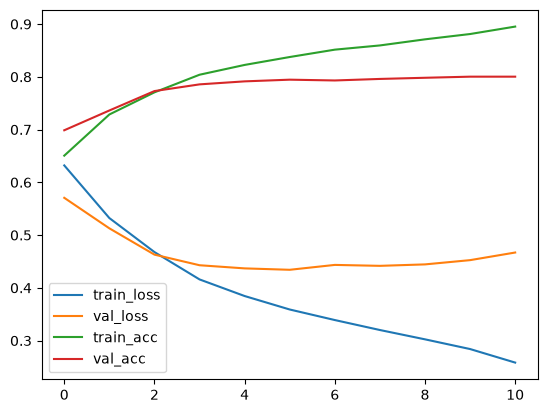

In [36]:
# 시각화 
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'train_loss' : train_losses,
    'val_loss' : val_losses,
    'train_acc' : train_accs,
    'val_acc' : val_accs,
})

df.plot()

In [41]:
# 테스트 데이터로 검증
def evaluate_model(model, test_dataloader, criterion, device):
    model.to(device).eval()
    test_loss, test_correct, test_total = 0, 0, 0
    with torch.no_grad():
        for test_inputs, test_labels in test_dataloader:
            test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

            output = model(test_inputs)
            loss = criterion(output, test_labels)

            test_loss += loss.item()
            p = torch.sigmoid(output)
            pred = (p >= 0.5).float()
            test_correct += (pred== test_labels).sum().float().detach().cpu().item()
            test_total += test_labels.size(0)
            
        test_loss = test_loss / len(test_dataloader)
        test_acc = test_correct /test_total
        
        return test_loss, test_acc
    


test_loss, test_acc = evaluate_model(model, test_dataloader, criterion, device)
print(f'Test Loss :{test_loss:.4f}, Test Acc : {test_acc:.4f}')

Test Loss :0.4818, Test Acc : 0.8010


In [ ]:
def movie_review_sentimental_analysis(sentences):
    
    
    tokens = [preprocessing(sent) for sent in sentences]        # 문장별 전처리
    encoded_sequences = tokenizer.texts_to_sequences(tokens)    # 단어를 정수 시퀀스로 변환
    padded_sequences = pad_sequences(encoded_sequences, maxlen= max_len)    # 고정 길이로 패딩/ 자르기
    
    X = torch.tensor(padded_sequences, dtype= torch.long).to(device)    # 입력데이터 LongTensor 변환
    
    model.eval()            # 평가 모드
    with torch.no_grad():   # 추론 시 기울기 계산안함
        output = model(X)   # 순전파(원시 logit 출력)
        p = torch.sigmoid(output)   # 0~1 확률로 변환
        pred = (p >= 0.5).float()   # True 면 1.0, Flase면 0.0
        
        return ['긍정' if pr == 1 else '부정' for pr in pred]
    
samples = [
    '이 영화는 못봐주겠네!',
    '오랜만에 감등을 느꼈다~',
    '감독이 생각이 있냐?',
    '내가 만들어도 이거보다 나을거같은데?',
    '재미없다',
    '재미가 있을까? 없을까?',
    '재미가 없을까? 있을까?',
    '재미있다'
]

movie_review_sentimental_analysis(samples)

['부정', '긍정', '부정', '부정', '부정', '부정', '부정', '긍정']